In [ ]:
import os
import struct
from array import array


class MNIST(object):
    def __init__(self, path='.'):
        self.path = path

        self.test_img_fname = 't10k-images-idx3-ubyte'
        self.test_lbl_fname = 't10k-labels-idx1-ubyte'

        self.train_img_fname = 'train-images-idx3-ubyte'
        self.train_lbl_fname = 'train-labels-idx1-ubyte'

        self.test_images = []
        self.test_labels = []

        self.train_images = []
        self.train_labels = []

    def load_testing(self):
        ims, labels = self.load(os.path.join(self.path, self.test_img_fname),
                                os.path.join(self.path, self.test_lbl_fname))

        self.test_images = ims
        self.test_labels = labels

        return ims, labels

    def load_training(self):
        ims, labels = self.load(os.path.join(self.path, self.train_img_fname),
                                os.path.join(self.path, self.train_lbl_fname))

        self.train_images = ims
        self.train_labels = labels

        return ims, labels

    @classmethod
    def load(cls, path_img, path_lbl):
        with open(path_lbl, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError('Magic number mismatch, expected 2049,'
                                 'got {}'.format(magic))

            labels = array("B", file.read())

        with open(path_img, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError('Magic number mismatch, expected 2051,'
                                 'got {}'.format(magic))

            image_data = array("B", file.read())

        images = []
        for i in range(size):
            images.append([0] * rows * cols)

        for i in range(size):
            images[i][:] = image_data[i * rows * cols:(i + 1) * rows * cols]

        return images, labels

    @classmethod
    def display(cls, img, width=28, threshold=200):
        render = ''
        for i in range(len(img)):
            if i % width == 0:
                render += '\n'
            if img[i] > threshold:
                render += '@'
            else:
                render += '.'
        return render


Loading MNIST Data...

Loading Training Data...

Loading Testing Data...

Preparing Classifier Training and Validation Data...

KNN Classifier with n_neighbors = 5, algorithm = auto, n_jobs = 10

Pickling the Classifier for Future Use...

Calculating Accuracy of trained Classifier...

Making Predictions on Validation Data...

Calculating Accuracy of Predictions...

Creating Confusion Matrix...

KNN Trained Classifier Confidence:  0.9733333333333334

Predicted Values:  [2 4 4 ... 5 3 8]

Accuracy of Classifier on Validation Image Data:  0.9733333333333334

Confusion Matrix: 
 [[597   0   0   0   0   0   3   0   0   1]
 [  0 692   1   1   0   0   0   4   0   0]
 [  3   5 548   0   1   0   2   9   1   0]
 [  0   1   0 545   0   9   0   3   1   3]
 [  0   6   0   0 584   0   2   2   0   8]
 [  2   1   1   5   0 558   9   0   0   2]
 [  1   1   0   0   0   1 572   0   0   0]
 [  0   4   2   0   1   0   0 608   0   6]
 [  2  11   4  10   1   8   3   0 560   4]
 [  2   0   0   1   8   1   0 

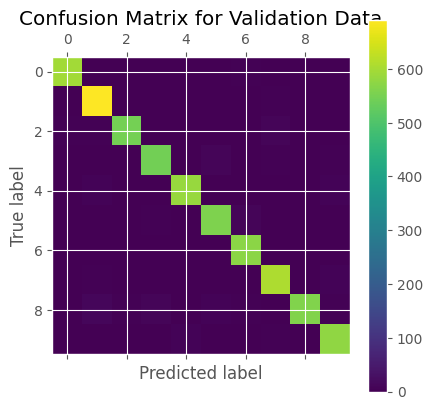


Making Predictions on Test Input Images...

Calculating Accuracy of Trained Classifier on Test Data... 

 Creating Confusion Matrix for Test Data...

Predicted Labels for Test Images:  [7 2 1 ... 4 5 6]

Accuracy of Classifier on Test Images:  0.968

Confusion Matrix for Test Data: 
 [[ 975    1    1    0    0    1    1    1    0    0]
 [   0 1130    2    0    0    0    2    0    0    1]
 [  12    7  989    2    2    0    1   16    3    0]
 [   0    3    1  979    1   10    1    8    3    4]
 [   3    8    0    0  944    0    4    3    1   19]
 [   6    0    0   11    2  862    4    2    1    4]
 [   5    2    0    0    3    2  946    0    0    0]
 [   0   21    4    0    4    0    0  989    0   10]
 [   8    3    5   16    6   14    4    6  908    4]
 [   6    7    3    9    7    3    1   12    3  958]]


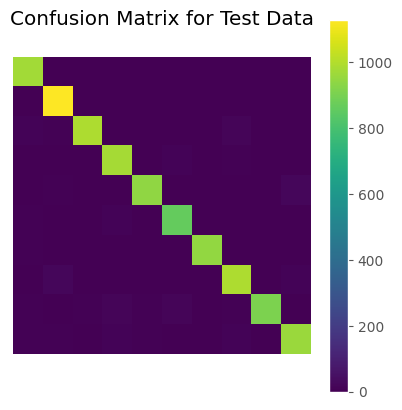

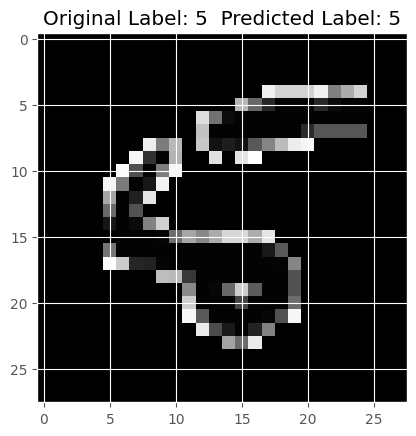

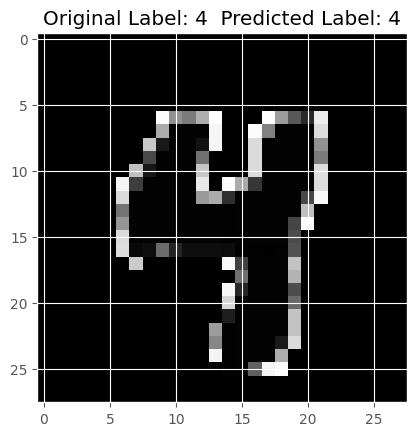

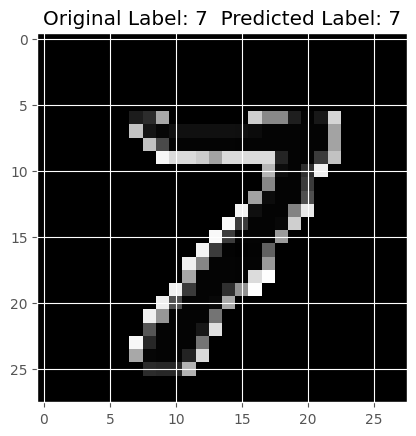

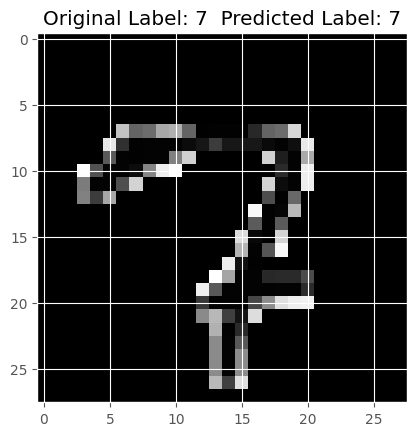

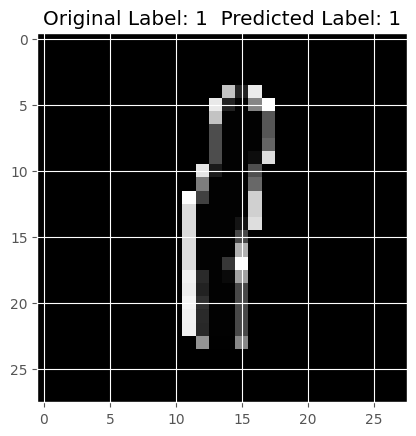

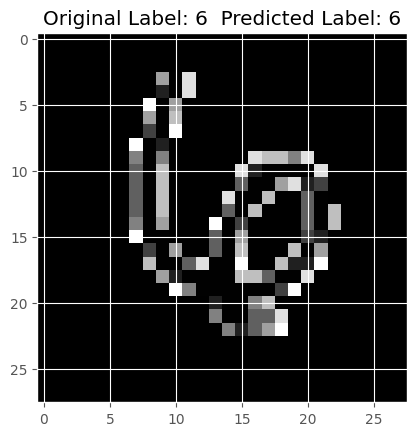

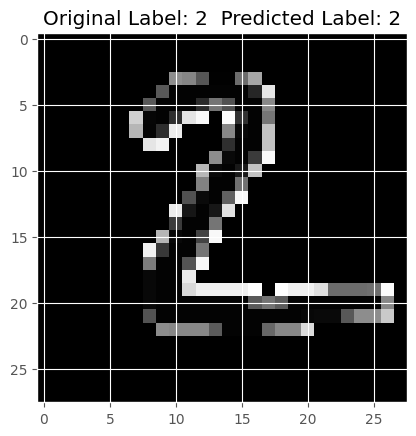

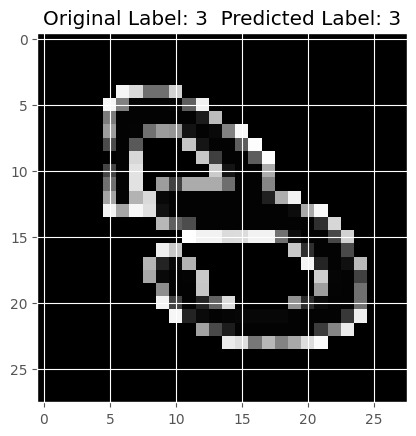

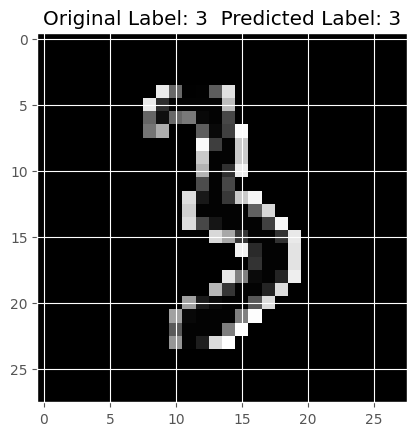

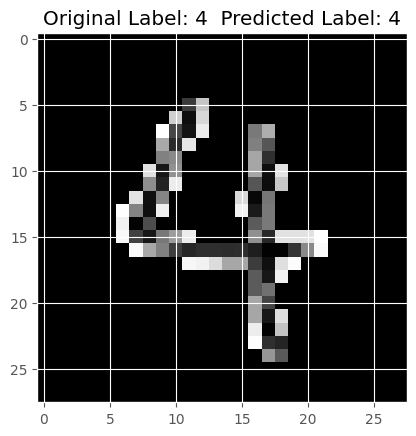

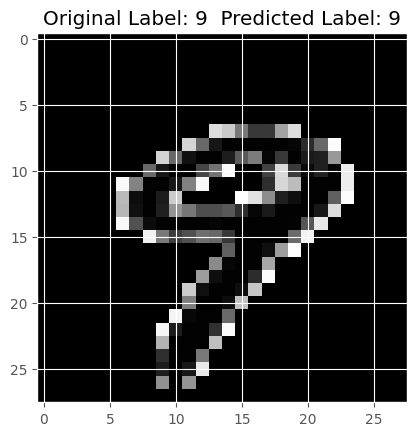

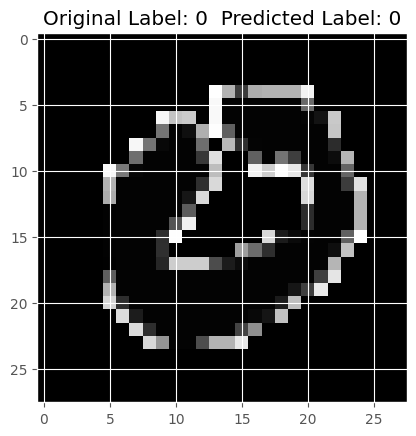

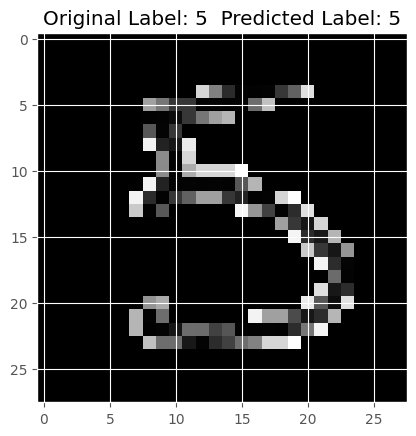

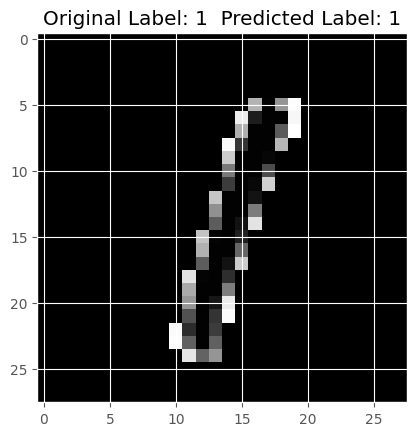

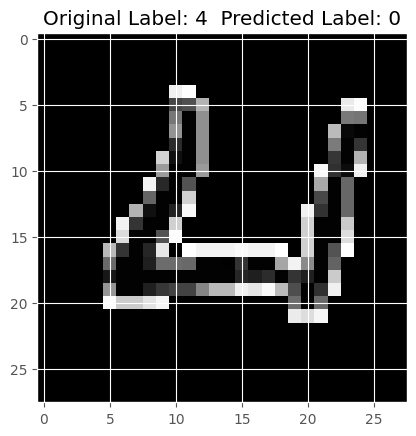

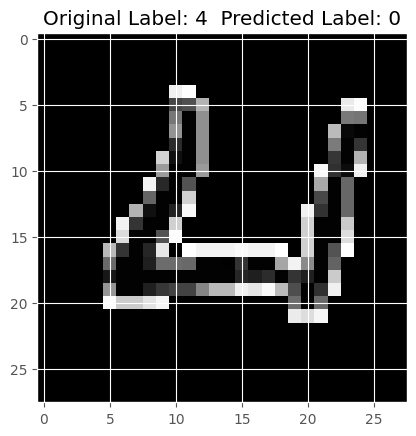

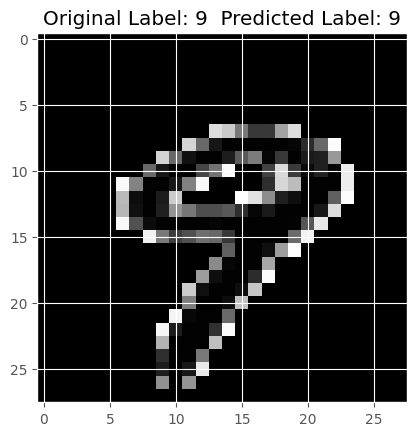

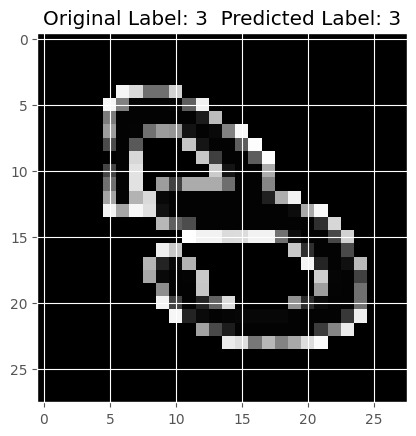

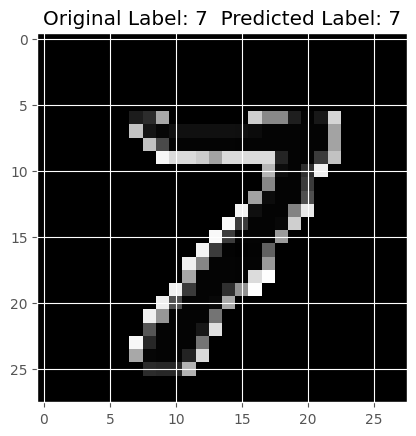

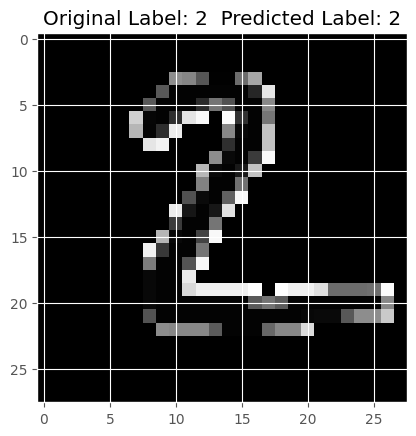

In [7]:
# K Nearest Neighbors

import sys
import numpy as np
import pickle
from sklearn import model_selection
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
# from MNIST_Dataset_Loader.mnist_loader import MNIST
import matplotlib.pyplot as plt
from matplotlib import style
style.use('ggplot')

# old_stdout = sys.stdout
# log_file = open("summary.log","w")
# sys.stdout = log_file


print('\nLoading MNIST Data...')
# data = MNIST('./python-mnist/data/')

data = MNIST('./MNIST_Dataset_Loader/dataset/')

print('\nLoading Training Data...')
img_train, labels_train = data.load_training()
train_img = np.array(img_train)
train_labels = np.array(labels_train)

print('\nLoading Testing Data...')
img_test, labels_test = data.load_testing()
test_img = np.array(img_test)
test_labels = np.array(labels_test)


#Features
X = train_img

#Labels
y = train_labels

print('\nPreparing Classifier Training and Validation Data...')
X_train, X_test, y_train, y_test = model_selection.train_test_split(X,y,test_size=0.1)


print('\nKNN Classifier with n_neighbors = 5, algorithm = auto, n_jobs = 10')
print('\nPickling the Classifier for Future Use...')
clf = KNeighborsClassifier(n_neighbors=5,algorithm='auto',n_jobs=10)
clf.fit(X_train,y_train)

with open('MNIST_KNN.pickle','wb') as f:
	pickle.dump(clf, f)

pickle_in = open('MNIST_KNN.pickle','rb')
clf = pickle.load(pickle_in)

print('\nCalculating Accuracy of trained Classifier...')
confidence = clf.score(X_test,y_test)

print('\nMaking Predictions on Validation Data...')
y_pred = clf.predict(X_test)

print('\nCalculating Accuracy of Predictions...')
accuracy = accuracy_score(y_test, y_pred)

print('\nCreating Confusion Matrix...')
conf_mat = confusion_matrix(y_test,y_pred)

print('\nKNN Trained Classifier Confidence: ',confidence)
print('\nPredicted Values: ',y_pred)
print('\nAccuracy of Classifier on Validation Image Data: ',accuracy)
print('\nConfusion Matrix: \n',conf_mat)


# Plot Confusion Matrix Data as a Matrix
plt.matshow(conf_mat)
plt.title('Confusion Matrix for Validation Data')
plt.colorbar()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()


print('\nMaking Predictions on Test Input Images...')
test_labels_pred = clf.predict(test_img)

print('\nCalculating Accuracy of Trained Classifier on Test Data... ')
acc = accuracy_score(test_labels,test_labels_pred)

print('\n Creating Confusion Matrix for Test Data...')
conf_mat_test = confusion_matrix(test_labels,test_labels_pred)

print('\nPredicted Labels for Test Images: ',test_labels_pred)
print('\nAccuracy of Classifier on Test Images: ',acc)
print('\nConfusion Matrix for Test Data: \n',conf_mat_test)

# Plot Confusion Matrix for Test Data
plt.matshow(conf_mat_test)
plt.title('Confusion Matrix for Test Data')
plt.colorbar()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.axis('off')
plt.show()

# sys.stdout = old_stdout
# log_file.close()



# Show the Test Images with Original and Predicted Labels
a = np.random.randint(1,50,20)
for i in a:
	two_d = (np.reshape(test_img[i], (28, 28)) * 255).astype(np.uint8)
	plt.title('Original Label: {0}  Predicted Label: {1}'.format(test_labels[i],test_labels_pred[i]))
	plt.imshow(two_d, interpolation='nearest',cmap='gray')
	plt.show()
#------------------------- EOC -----------------------------



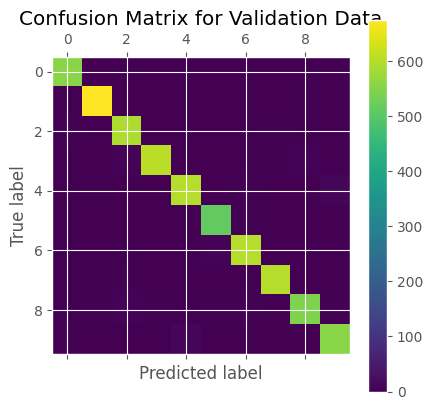

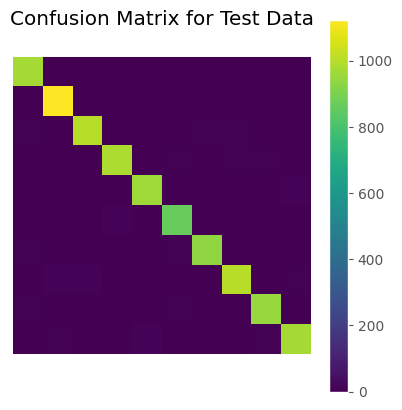

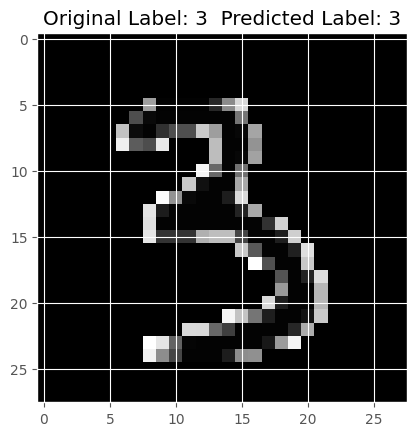

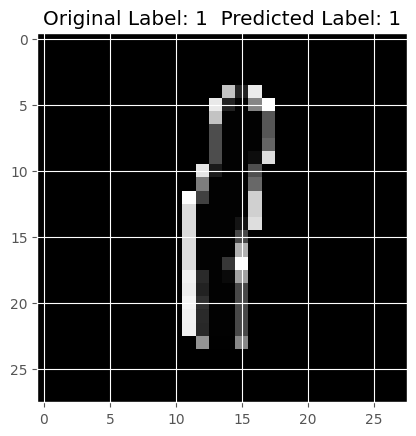

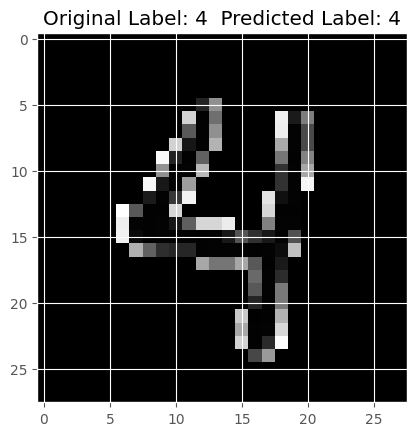

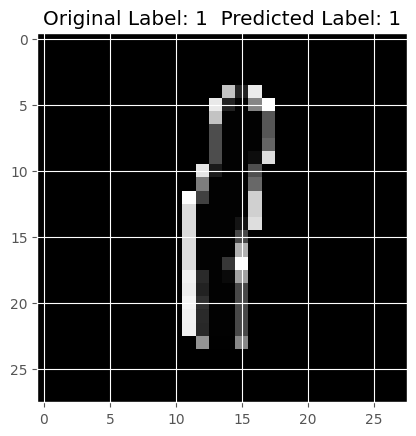

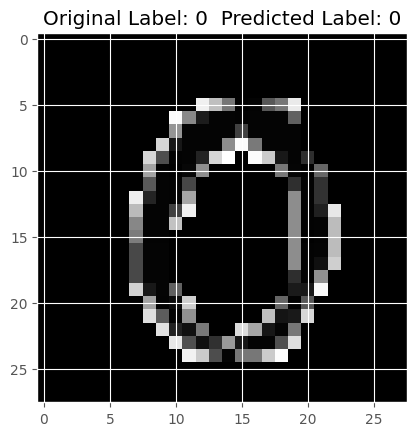

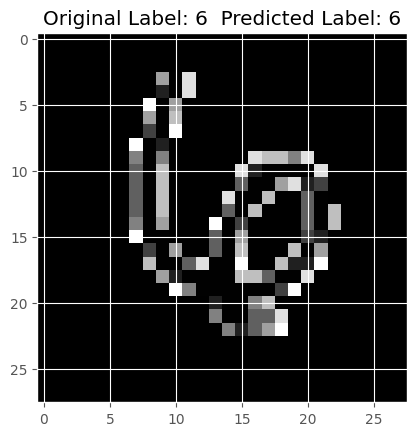

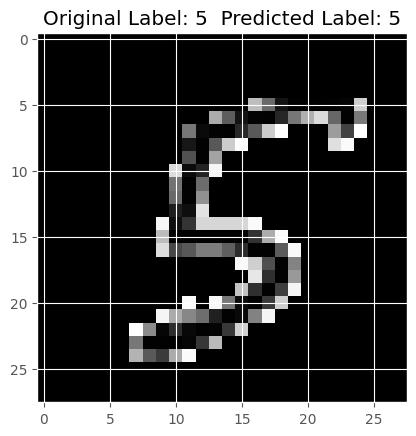

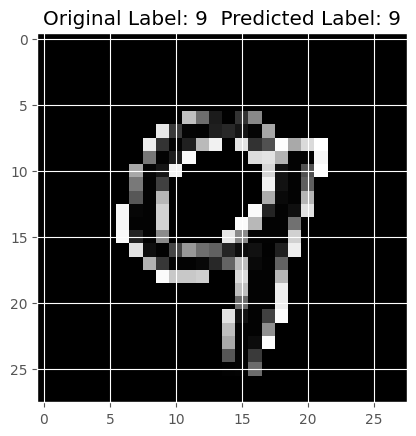

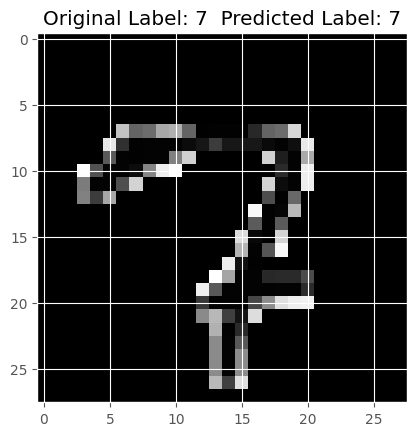

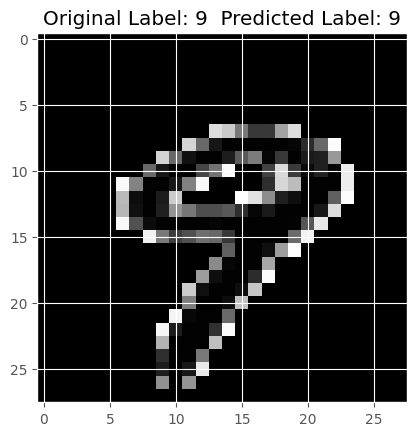

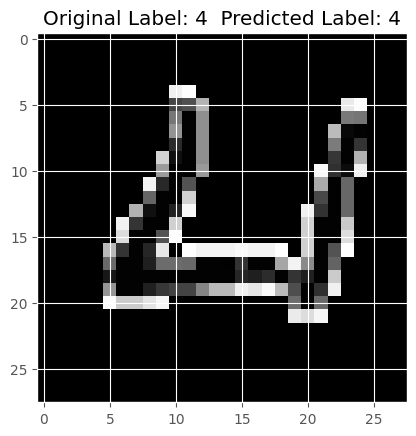

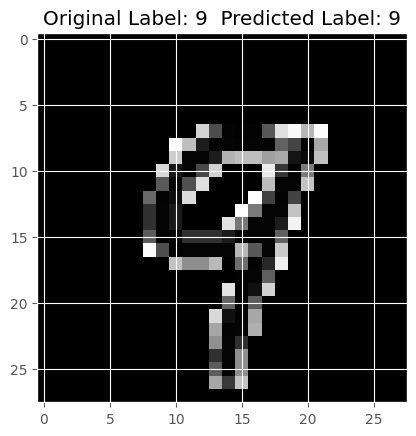

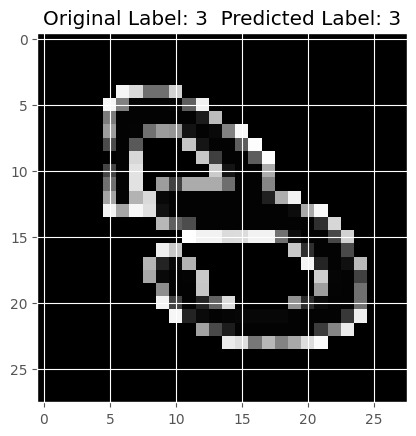

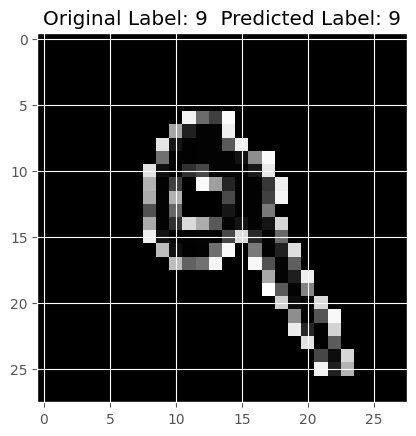

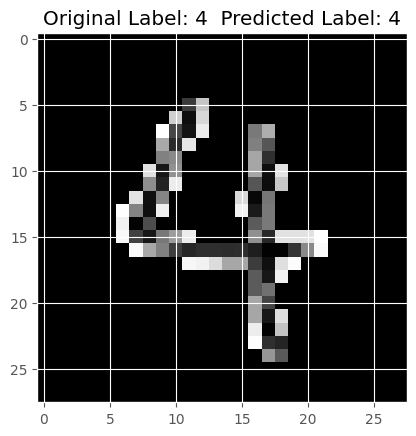

In [9]:
import sys
import numpy as np
import pickle
from sklearn import model_selection, svm, preprocessing
from sklearn.metrics import accuracy_score,confusion_matrix
# from MNIST_Dataset_Loader.mnist_loader import MNIST
import matplotlib.pyplot as plt
from matplotlib import style
style.use('ggplot')


# Save all the Print Statements in a Log file.
old_stdout = sys.stdout
log_file = open("summary.log","w")
sys.stdout = log_file

# Load MNIST Data
print('\nLoading MNIST Data...')
data = MNIST('./MNIST_Dataset_Loader/dataset/')

print('\nLoading Training Data...')
img_train, labels_train = data.load_training()
train_img = np.array(img_train)
train_labels = np.array(labels_train)

print('\nLoading Testing Data...')
img_test, labels_test = data.load_testing()
test_img = np.array(img_test)
test_labels = np.array(labels_test)


#Features
X = train_img

#Labels
y = train_labels

# Prepare Classifier Training and Testing Data
print('\nPreparing Classifier Training and Validation Data...')
X_train, X_test, y_train, y_test = model_selection.train_test_split(X,y,test_size=0.1)


# Pickle the Classifier for Future Use
print('\nSVM Classifier with gamma = 0.1; Kernel = polynomial')
print('\nPickling the Classifier for Future Use...')
clf = svm.SVC(gamma=0.1, kernel='poly')
clf.fit(X_train,y_train)

with open('MNIST_SVM.pickle','wb') as f:
	pickle.dump(clf, f)

pickle_in = open('MNIST_SVM.pickle','rb')
clf = pickle.load(pickle_in)

print('\nCalculating Accuracy of trained Classifier...')
acc = clf.score(X_test,y_test)

print('\nMaking Predictions on Validation Data...')
y_pred = clf.predict(X_test)

print('\nCalculating Accuracy of Predictions...')
accuracy = accuracy_score(y_test, y_pred)

print('\nCreating Confusion Matrix...')
conf_mat = confusion_matrix(y_test,y_pred)

print('\nSVM Trained Classifier Accuracy: ',acc)
print('\nPredicted Values: ',y_pred)
print('\nAccuracy of Classifier on Validation Images: ',accuracy)
print('\nConfusion Matrix: \n',conf_mat)

# Plot Confusion Matrix Data as a Matrix
plt.matshow(conf_mat)
plt.title('Confusion Matrix for Validation Data')
plt.colorbar()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()


print('\nMaking Predictions on Test Input Images...')
test_labels_pred = clf.predict(test_img)

print('\nCalculating Accuracy of Trained Classifier on Test Data... ')
acc = accuracy_score(test_labels,test_labels_pred)

print('\n Creating Confusion Matrix for Test Data...')
conf_mat_test = confusion_matrix(test_labels,test_labels_pred)

print('\nPredicted Labels for Test Images: ',test_labels_pred)
print('\nAccuracy of Classifier on Test Images: ',acc)
print('\nConfusion Matrix for Test Data: \n',conf_mat_test)

# Plot Confusion Matrix for Test Data
plt.matshow(conf_mat_test)
plt.title('Confusion Matrix for Test Data')
plt.colorbar()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.axis('off')
plt.show()

sys.stdout = old_stdout
log_file.close()


# Show the Test Images with Original and Predicted Labels
a = np.random.randint(1,40,15)
for i in a:
	two_d = (np.reshape(test_img[i], (28, 28)) * 255).astype(np.uint8)
	plt.title('Original Label: {0}  Predicted Label: {1}'.format(test_labels[i],test_labels_pred[i]))
	plt.imshow(two_d, interpolation='nearest',cmap='gray')
	plt.show()
#---------------------- EOC ---------------------#



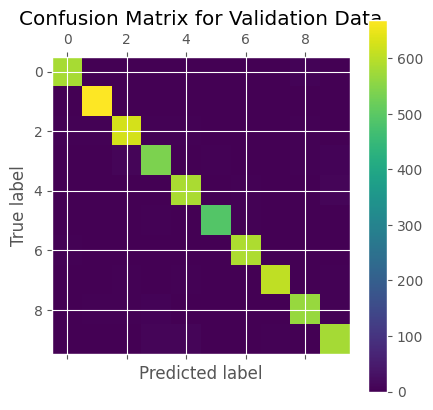

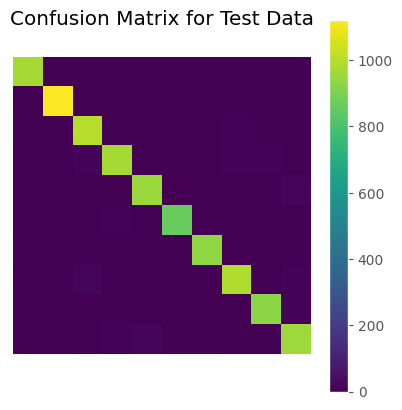

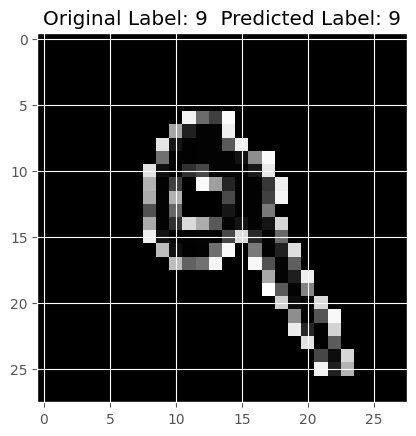

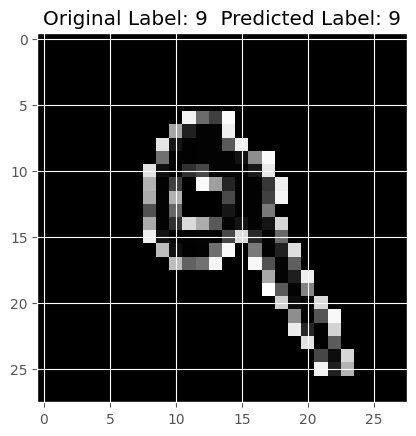

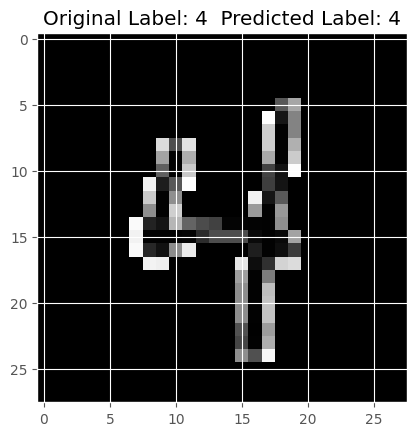

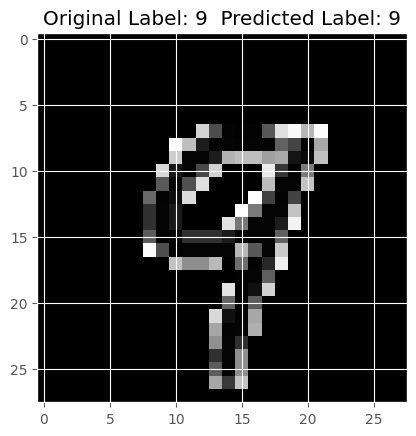

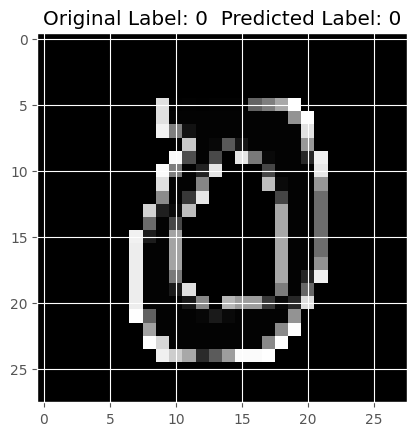

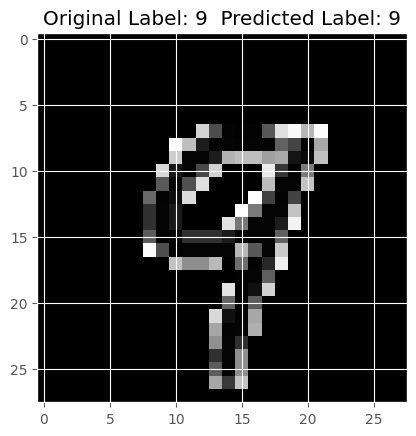

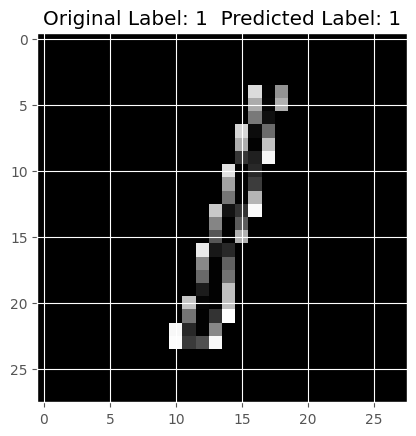

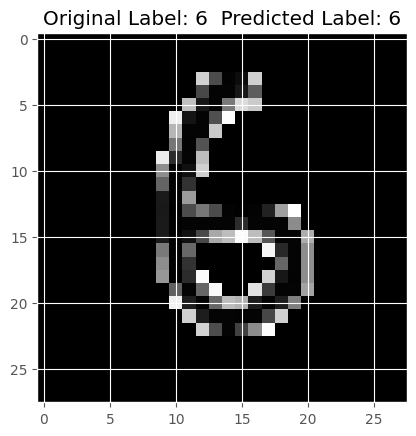

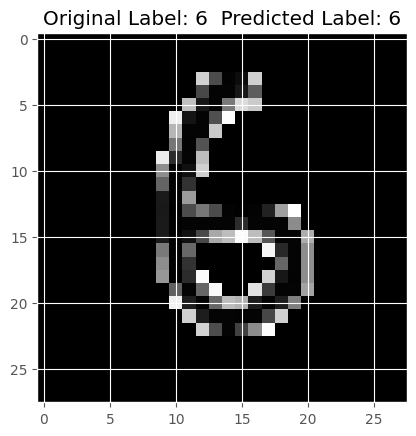

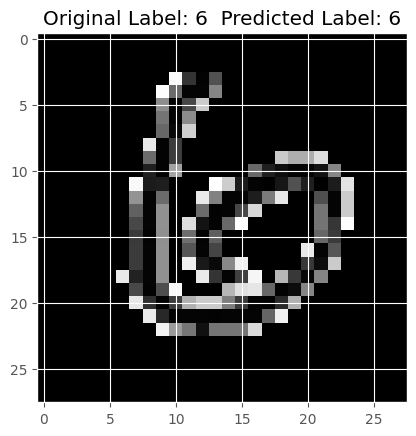

In [10]:
# Random Forest Classifier

import sys
import numpy as np
import pickle
from sklearn import model_selection
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
# from MNIST_Dataset_Loader.mnist_loader import MNIST
import matplotlib.pyplot as plt
from matplotlib import style
style.use('ggplot')



old_stdout = sys.stdout
log_file = open("summary.log","w")
sys.stdout = log_file


print('\nLoading MNIST Data...')
# data = MNIST('./python-mnist/data/')

data = MNIST('./MNIST_Dataset_Loader/dataset/')

print('\nLoading Training Data...')
img_train, labels_train = data.load_training()
train_img = np.array(img_train)
train_labels = np.array(labels_train)

print('\nLoading Testing Data...')
img_test, labels_test = data.load_testing()
test_img = np.array(img_test)
test_labels = np.array(labels_test)


#Features
X = train_img

#Labels
y = train_labels

print('\nPreparing Classifier Training and Validation Data...')
X_train, X_test, y_train, y_test = model_selection.train_test_split(X,y,test_size=0.1)


print('\nRandom Forest Classifier with n_estimators = 100, n_jobs = 10')
print('\nPickling the Classifier for Future Use...')
clf = RandomForestClassifier(n_estimators=100, n_jobs=10)
clf.fit(X_train,y_train)

with open('MNIST_RFC.pickle','wb') as f:
	pickle.dump(clf, f)

pickle_in = open('MNIST_RFC.pickle','rb')
clf = pickle.load(pickle_in)

print('\nCalculating Accuracy of trained Classifier...')
confidence = clf.score(X_test,y_test)

print('\nMaking Predictions on Validation Data...')
y_pred = clf.predict(X_test)

print('\nCalculating Accuracy of Predictions...')
accuracy = accuracy_score(y_test, y_pred)

print('\nCreating Confusion Matrix...')
conf_mat = confusion_matrix(y_test,y_pred)

print('\nRFC Trained Classifier Confidence: ',confidence)
print('\nPredicted Values: ',y_pred)
print('\nAccuracy of Classifier on Validation Image Data: ',accuracy)
print('\nConfusion Matrix: \n',conf_mat)


# Plot Confusion Matrix Data as a Matrix
plt.matshow(conf_mat)
plt.title('Confusion Matrix for Validation Data')
plt.colorbar()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()


print('\nMaking Predictions on Test Input Images...')
test_labels_pred = clf.predict(test_img)

print('\nCalculating Accuracy of Trained Classifier on Test Data... ')
acc = accuracy_score(test_labels,test_labels_pred)

print('\n Creating Confusion Matrix for Test Data...')
conf_mat_test = confusion_matrix(test_labels,test_labels_pred)

print('\nPredicted Labels for Test Images: ',test_labels_pred)
print('\nAccuracy of Classifier on Test Images: ',acc)
print('\nConfusion Matrix for Test Data: \n',conf_mat_test)

# Plot Confusion Matrix for Test Data
plt.matshow(conf_mat_test)
plt.title('Confusion Matrix for Test Data')
plt.colorbar()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.axis('off')
plt.show()

sys.stdout = old_stdout
log_file.close()


# Show the Test Images with Original and Predicted Labels
a = np.random.randint(1,30,10)
for i in a:
	two_d = (np.reshape(test_img[i], (28, 28)) * 255).astype(np.uint8)
	plt.title('Original Label: {0}  Predicted Label: {1}'.format(test_labels[i],test_labels_pred[i]))
	plt.imshow(two_d, interpolation='nearest',cmap='gray')
	plt.show()
#------------------------- EOC -----------------------------



In [29]:
import numpy as np
import cv2
import argparse
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# TensorFlow/Keras imports
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Activation, Flatten, Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import SGD

# -----------------------------
# Argument parser (safe for Jupyter)
parser = argparse.ArgumentParser()
parser.add_argument("-s", "--save_model", type=str, help="Path to save model")
parser.add_argument("-l", "--load_model", type=str, help="Path to load model")
parser.add_argument("-w", "--save_weights", type=str, help="Path to save weights")
args, unknown = parser.parse_known_args()

# -----------------------------
# Load MNIST dataset
print("Loading MNIST Dataset...")
dataset = fetch_openml("mnist_784", version=1)

X = dataset.data.astype("float32") / 255.0
y = dataset.target.astype("int")

# Reshape into (N, 28, 28, 1) for CNN input
X = X.values.reshape((-1, 28, 28, 1))

# Train/test split
train_img, test_img, train_labels, test_labels = train_test_split(
    X, y, test_size=0.1, random_state=42
)

# One-hot encode labels
train_labels = to_categorical(train_labels, 10)
test_labels = to_categorical(test_labels, 10)

# -----------------------------
# Define CNN model
def build_cnn(width=28, height=28, depth=1, classes=10):
    model = Sequential()
    model.add(Conv2D(32, (3, 3), padding="same", input_shape=(height, width, depth)))
    model.add(Activation("relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(64, (3, 3), padding="same"))
    model.add(Activation("relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Flatten())
    model.add(Dense(128))
    model.add(Activation("relu"))

    model.add(Dense(classes))
    model.add(Activation("softmax"))
    return model

# -----------------------------
# Compile model
print("\nCompiling model...")
sgd = SGD(learning_rate=0.01, decay=1e-6, momentum=0.9, nesterov=True)
clf = build_cnn()
clf.compile(loss="categorical_crossentropy", optimizer=sgd, metrics=["accuracy"])

# -----------------------------
# Train model
print("\nTraining the Model...")
clf.fit(train_img, train_labels, batch_size=128, epochs=5, verbose=1)

# Evaluate model
print("\nEvaluating Accuracy and Loss Function...")
loss, accuracy = clf.evaluate(test_img, test_labels, batch_size=128, verbose=1)
print("Accuracy of Model: {:.2f}%".format(accuracy * 100))

# -----------------------------
# Show predictions for random samples
for num in np.random.choice(np.arange(0, len(test_labels)), size=(5,)):
    probs = clf.predict(test_img[np.newaxis, num])
    prediction = probs.argmax(axis=1)

    image = (test_img[num][:, :, 0] * 255).astype("uint8")
    image = cv2.merge([image] * 3)
    image = cv2.resize(image, (100, 100), interpolation=cv2.INTER_LINEAR)
    cv2.putText(image, str(prediction[0]), (5, 20),
                cv2.FONT_HERSHEY_SIMPLEX, 0.75, (0, 255, 0), 2)

    print("Predicted Label: {}, Actual Value: {}".format(
        prediction[0], np.argmax(test_labels[num])
    ))
    # Uncomment if you want to see images in Colab (requires cv2.imshow in local env)
    # cv2.imshow("Digits", image)
    # cv2.waitKey(0)


Loading MNIST Dataset...

Compiling model...


/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training the Model...
Epoch 1/5
493/493 ━━━━━━━━━━━━━━━━━━━━ 75s 148ms/step - accuracy: 0.8975 - loss: 0.3575
Epoch 2/5
493/493 ━━━━━━━━━━━━━━━━━━━━ 72s 146ms/step - accuracy: 0.9758 - loss: 0.0794
Epoch 3/5
493/493 ━━━━━━━━━━━━━━━━━━━━ 72s 146ms/step - accuracy: 0.9818 - loss: 0.0569
Epoch 4/5
493/493 ━━━━━━━━━━━━━━━━━━━━ 82s 147ms/step - accuracy: 0.9860 - loss: 0.0452
Epoch 5/5
493/493 ━━━━━━━━━━━━━━━━━━━━ 72s 147ms/step - accuracy: 0.9883 - loss: 0.0371

Evaluating Accuracy and Loss Function...
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.9829 - loss: 0.0548
Accuracy of Model: 98.29%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
Predicted Label: 1, Actual Value: 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predicted Label: 6, Actual Value: 6
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Predicted Label: 2, Actual Value: 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predicted Label: 0, Actual Value: 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predicted Label: 8, Actual Value: 8
